# Baseline vs Sentiment-Enhanced Model

Does this stock **beat SPY** over the next 10 trading days? (relative performance)\n- Fixes regime bias — base rate stays ~50% regardless of bull/bear market\n- Better than absolute `>2%` which was 38% in 2022, 49% in 2023\n\n**Threshold**: `0.35` instead of default `0.50`\n- Fixes DOWN-bias — model's P(Beat) mean ≈ 0.41, so default 0.5 predicts DOWN 96% of the time\n\n**Models compared**:\n- A: Technical features only\n- B: + Ticker encoding\n- C: + Ticker + Sentiment dynamics (change, momentum, count, weighted)

In [46]:
import pandas as pd
import numpy as np
import glob
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

BASE_SENTIMENT_COLS = [
    "sentiment_mean", "sentiment_count", "sentiment_std",
    "sentiment_change", "sentiment_3d", "sentiment_7d"
]
SENTIMENT_COLS = [
    "sentiment_mean",
    "sentiment_count",
    "sentiment_change",
    "sentiment_momentum",   # 3d - 7d
    "sentiment_weighted",   # mean × log(1+count)
]

DATA_START   = "2022-01-01"
TRAIN_CUTOFF = "2024-01-01"
THRESHOLD    = 0.35          # Fix 1: lower than 0.5 to fix DOWN bias

In [47]:
# ── Load baseline features + Fix 2: recompute target relative to SPY ──────────
base = pd.read_csv("../../data/processed/features/features_all.csv", parse_dates=["Date"])
base["Date"] = pd.to_datetime(base["Date"])
base = base[base["Date"] >= DATA_START].reset_index(drop=True)

# Download SPY as market benchmark
spy_raw = yf.download("SPY", start=DATA_START, progress=False)
spy_raw.columns = spy_raw.columns.get_level_values(0)
spy_ret = (spy_raw["Close"].shift(-10) / spy_raw["Close"] - 1).rename("spy_ret_10d")
spy_ret.index = pd.to_datetime(spy_ret.index)

# Compute per-stock 10-day forward return, then compare to SPY
base = base.sort_values(["symbol", "Date"]).reset_index(drop=True)
base["stock_ret_10d"] = base.groupby("symbol")["Close"].transform(
    lambda x: x.shift(-10) / x - 1
)
base = base.merge(spy_ret.reset_index().rename(columns={"Date": "Date"}), on="Date", how="left")

# Fix 2: target = does this stock BEAT the market in 10 days?
base["target"] = (base["stock_ret_10d"] > base["spy_ret_10d"]).astype(int)

print("Baseline data:", base.shape, "|", base["Date"].min().date(), "→", base["Date"].max().date())
print(f"\nTarget distribution (beat SPY in 10d):")
print(base["target"].value_counts())
print(f"Up rate per year:")
for yr, g in base.groupby(base["Date"].dt.year):
    print(f"  {yr}: {g['target'].mean()*100:.1f}%  ← should be ~50% always")

Baseline data: (5271, 35) | 2022-01-03 → 2024-12-31

Target distribution (beat SPY in 10d):
target
1    2702
0    2569
Name: count, dtype: int64
Up rate per year:
  2022: 44.4%  ← should be ~50% always
  2023: 57.2%  ← should be ~50% always
  2024: 52.2%  ← should be ~50% always


In [48]:
# ── Load & stack all sentiment CSVs ───────────────────────────────────────────
sent_files = glob.glob("../../data/processed/sentiment/sentiment_features_*.csv")
print(f"Found {len(sent_files)} sentiment files")

sent_frames = []
for path in sent_files:
    ticker = path.split("_")[-1].replace(".csv", "")
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    df["symbol"] = ticker
    df["Date"] = df.index
    sent_frames.append(df[["Date", "symbol"] + BASE_SENTIMENT_COLS])  # โหลดแค่ base cols

sent = pd.concat(sent_frames, ignore_index=True)
print("Sentiment data:", sent.shape, "|", sent['Date'].min().date(), "→", sent['Date'].max().date())

Found 7 sentiment files
Sentiment data: (7616, 8) | 2022-01-03 → 2026-05-05


In [49]:
# ── Merge + engineer sentiment features + encode ticker ───────────────────────
df = base.merge(sent, on=["Date", "symbol"], how="left")
df[BASE_SENTIMENT_COLS] = df[BASE_SENTIMENT_COLS].fillna(0)

# Dynamics — ทั้งหมดคำนวณตรงจาก CSV ไม่ต้องใช้ per-group transform
df["sentiment_momentum"] = df["sentiment_3d"] - df["sentiment_7d"]
df["sentiment_weighted"]  = df["sentiment_mean"] * np.log1p(df["sentiment_count"])

# Ticker เป็น numeric
le = LabelEncoder()
df["ticker_encoded"] = le.fit_transform(df["symbol"])
print("Ticker map:", dict(zip(le.classes_, le.transform(le.classes_))))

nz = (df["sentiment_change"] != 0).sum()
print(f"\nRows with sentiment signal: {nz} / {len(df)} ({nz/len(df)*100:.1f}%)")

Ticker map: {'AAPL': np.int64(0), 'AMZN': np.int64(1), 'BAC': np.int64(2), 'JPM': np.int64(3), 'MSFT': np.int64(4), 'NVDA': np.int64(5), 'TSLA': np.int64(6)}

Rows with sentiment signal: 3895 / 5271 (73.9%)


In [50]:
# ── Define feature sets ───────────────────────────────────────────────────────
DROP_COLS = ["Date", "symbol", "target", "Open", "High", "Low", "Close", "Volume"]
technical_features  = [c for c in base.columns if c not in DROP_COLS]
ticker_features     = technical_features + ["ticker_encoded"]
sentiment_features  = ticker_features + SENTIMENT_COLS

print(f"[A] Technical only     : {len(technical_features)} features")
print(f"[B] + Ticker           : {len(ticker_features)} features")
print(f"[C] + Ticker+Sentiment : {len(sentiment_features)} features")

[A] Technical only     : 27 features
[B] + Ticker           : 28 features
[C] + Ticker+Sentiment : 33 features


In [51]:
# ── Train/test split — ทั้งสองช่วงมี sentiment data จริง ──────────────────────
train = df[df["Date"] < TRAIN_CUTOFF].dropna(subset=technical_features + ["target"])
test  = df[df["Date"] >= TRAIN_CUTOFF].dropna(subset=technical_features + ["target"])

for label, g in [("Train", train), ("Test", test)]:
    nz = (g["sentiment_mean"] != 0).sum()
    print(f"{label}: {len(g)} rows ({g['Date'].min().date()} → {g['Date'].max().date()})  sentiment coverage: {nz/len(g)*100:.0f}%")

Train: 3507 rows (2022-01-03 → 2023-12-29)  sentiment coverage: 57%
Test: 1694 rows (2024-01-02 → 2024-12-16)  sentiment coverage: 90%


In [52]:
# ── Train 3 variants — predict_proba + THRESHOLD instead of default 0.5 ───────
MODELS = [
    ("A: Technical",          technical_features),
    ("B: +Ticker",            ticker_features),
    ("C: +Ticker+Sentiment",  sentiment_features),
]

results = {}
for name, features in MODELS:
    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[features], train["target"])
    proba = model.predict_proba(test[features])[:, 1]
    pred  = (proba >= THRESHOLD).astype(int)          # Fix 1: threshold=0.35
    n_up  = pred.sum()

    results[name] = {
        "model": model, "features": features,
        "pred": pred, "proba": proba,
        "acc":  accuracy_score(test["target"], pred),
        "prec": precision_score(test["target"], pred, pos_label=1, zero_division=0),
        "rec":  recall_score(test["target"], pred, pos_label=1, zero_division=0),
        "n_up": n_up,
    }

print(f"{'Model':<30} {'Acc':>6} {'Prec(Up)':>10} {'Rec(Up)':>9} {'#UpPred':>8}  (threshold={THRESHOLD})")
print("-" * 72)
for name, r in results.items():
    print(f"{name:<30} {r['acc']:>6.3f} {r['prec']:>10.3f} {r['rec']:>9.3f} {r['n_up']:>8}")

print()
print(classification_report(test["target"], results["C: +Ticker+Sentiment"]["pred"],
                             target_names=["Lag Market", "Beat Market"]))

Model                             Acc   Prec(Up)   Rec(Up)  #UpPred  (threshold=0.35)
------------------------------------------------------------------------
A: Technical                    0.893      0.843     0.987     1078
B: +Ticker                      0.897      0.849     0.986     1070
C: +Ticker+Sentiment            0.885      0.833     0.986     1090

              precision    recall  f1-score   support

  Lag Market       0.98      0.76      0.86       773
 Beat Market       0.83      0.99      0.90       921

    accuracy                           0.88      1694
   macro avg       0.91      0.88      0.88      1694
weighted avg       0.90      0.88      0.88      1694



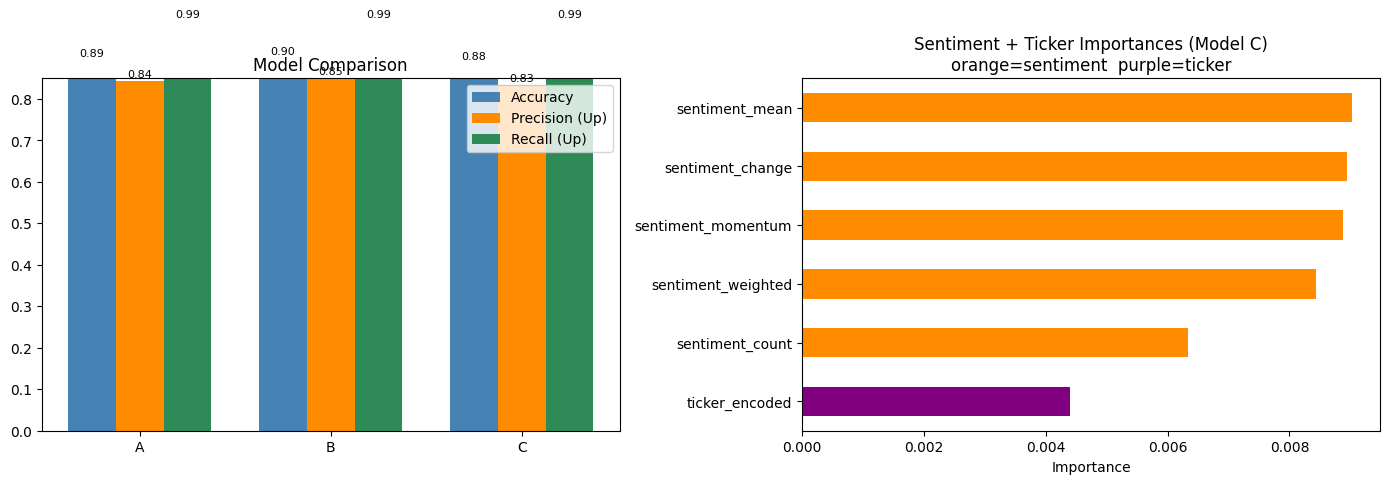

In [53]:
# ── Comparison chart ──────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

names = list(results.keys())
accs  = [results[n]["acc"] for n in names]
prec1 = [precision_score(test["target"], results[n]["pred"], pos_label=1) for n in names]
rec1  = [recall_score(test["target"], results[n]["pred"], pos_label=1)    for n in names]

x = np.arange(len(names))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy + precision + recall bars
for i, (vals, label, color) in enumerate([
    (accs, "Accuracy", "steelblue"),
    (prec1, "Precision (Up)", "darkorange"),
    (rec1,  "Recall (Up)",    "seagreen"),
]):
    bars = axes[0].bar(x + i*width, vals, width, label=label, color=color)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{v:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels([n.split(":")[0] for n in names])
axes[0].set_ylim(0, 0.85)
axes[0].legend()
axes[0].set_title("Model Comparison")

# Right: sentiment feature importances for model C
model_c   = results["C: +Ticker+Sentiment"]["model"]
feat_c    = results["C: +Ticker+Sentiment"]["features"]
imp_c     = pd.Series(model_c.feature_importances_, index=feat_c)
sent_imp  = imp_c[SENTIMENT_COLS + ["ticker_encoded"]].sort_values()
colors    = ["darkorange" if c in SENTIMENT_COLS else "purple" for c in sent_imp.index]
sent_imp.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Sentiment + Ticker Importances (Model C)\norange=sentiment  purple=ticker")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

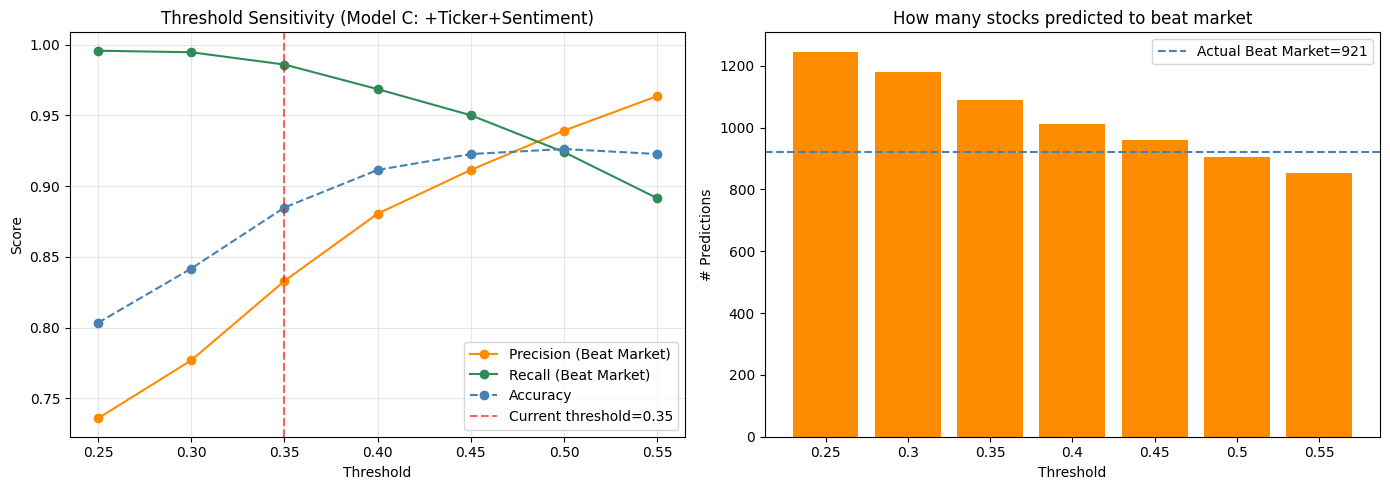


Threshold table:
 threshold  accuracy  precision  recall  n_up
     0.250     0.803      0.736   0.996  1246
     0.300     0.842      0.777   0.995  1179
     0.350     0.885      0.833   0.986  1090
     0.400     0.911      0.881   0.969  1013
     0.450     0.923      0.911   0.950   960
     0.500     0.926      0.939   0.924   906
     0.550     0.923      0.964   0.891   852


In [54]:
# ── Threshold sensitivity — find best precision/recall tradeoff ───────────────
model_c  = results["C: +Ticker+Sentiment"]["model"]
proba_c  = results["C: +Ticker+Sentiment"]["proba"]
y_test   = test["target"].values

thresholds = np.arange(0.25, 0.56, 0.05)
rows = []
for t in thresholds:
    pred = (proba_c >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall":    recall_score(y_test, pred, pos_label=1, zero_division=0),
        "n_up":      pred.sum(),
    })
tdf = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: precision / recall vs threshold
axes[0].plot(tdf["threshold"], tdf["precision"], "o-", color="darkorange", label="Precision (Beat Market)")
axes[0].plot(tdf["threshold"], tdf["recall"],    "o-", color="seagreen",   label="Recall (Beat Market)")
axes[0].plot(tdf["threshold"], tdf["accuracy"],  "o--", color="steelblue", label="Accuracy")
axes[0].axvline(THRESHOLD, color="red", linestyle="--", alpha=0.6, label=f"Current threshold={THRESHOLD}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Threshold Sensitivity (Model C: +Ticker+Sentiment)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: number of "Beat Market" predictions vs threshold
axes[1].bar(tdf["threshold"].round(2).astype(str), tdf["n_up"], color="darkorange")
axes[1].axhline(y_test.sum(), color="steelblue", linestyle="--", label=f"Actual Beat Market={y_test.sum()}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("# Predictions")
axes[1].set_title("How many stocks predicted to beat market")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nThreshold table:")
print(tdf.to_string(index=False, float_format="{:.3f}".format))